In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark

E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jre-headless_8u472-ga-1%7e22.04_amd64.deb  404  Not Found [IP: 185.125.190.81 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jdk-headless_8u472-ga-1%7e22.04_amd64.deb  404  Not Found [IP: 185.125.190.81 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?


In [2]:
from pyspark.sql import SparkSession

# Создаем сессию
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("WineQualityClassification") \
    .getOrCreate()

print("Spark Session создана")

Spark Session создана


In [3]:
import pandas as pd

# Скачиваем данные по вину и конвертируем в Spark DataFrame
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
pd_df = pd.read_csv(url, sep=';')
df = spark.createDataFrame(pd_df)

df.show(5)
df.printSchema()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [4]:
# Взяла за основу датасед по качеству вина.
# Буду строить модель Рандом форест, чтобы предсказать, является ли вино хорошим
# по составу (химическому)

In [5]:
from pyspark.sql.functions import when
# Для классификации нам нужно сделать целевую метку бинарной
# (например, 1 — хорошее вино, если рейтинг больше либо равно 7, и 0 — посредственное).

# Создаем колонку 'label': 1 (качество >= 7), иначе 0
df = df.withColumn("label", when(df["quality"] >= 7, 1).otherwise(0))

# Удаляем старую колонку quality, чтобы модель не "подглядывала" в ответ
df = df.drop("quality")

df.select("label").groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1|  217|
|    0| 1382|
+-----+-----+



In [6]:
from pyspark.ml.feature import VectorAssembler

# Список колонок-признаков (все, кроме label)
feature_cols = [col for col in df.columns if col != 'label']

# Собираем их в один вектор 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(df)

# Оставляем только нужные для обучения колонки
final_data = data.select("features", "label")
final_data.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[7.4,0.7,0.0,1.9,...|    0|
|[7.8,0.88,0.0,2.6...|    0|
|[7.8,0.76,0.04,2....|    0|
|[11.2,0.28,0.56,1...|    0|
|[7.4,0.7,0.0,1.9,...|    0|
+--------------------+-----+
only showing top 5 rows


In [7]:
from pyspark.ml.classification import RandomForestClassifier

# Делим на обучающую и тестовую выборки (80/20)
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

# Инициализируем модель
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20)

# Обучаем модель
model = rf.fit(train_data)
print("Модель обучена")

Модель обучена


In [8]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Делаем предсказания
predictions = model.transform(test_data)

# Оцениваем точность
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"Accuracy (Точность) модели: {accuracy:.2%}")
predictions.select("label", "prediction", "probability").show(10)

Accuracy (Точность) модели: 88.78%
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       0.0|[0.56523575852178...|
|    0|       0.0|[0.97426816356483...|
|    0|       0.0|[0.71289146935683...|
|    0|       0.0|[0.87635978469300...|
|    0|       0.0|[0.63189655730633...|
|    0|       0.0|[0.97553502947861...|
|    0|       0.0|[0.93271904004445...|
|    0|       0.0|[0.82738455226549...|
|    0|       0.0|[0.97731812032703...|
|    0|       0.0|[0.93304937031242...|
+-----+----------+--------------------+
only showing top 10 rows


In [9]:
# Дополнительно для визуализации (а почему бы и нет)

/tmp/ipython-input-65005606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


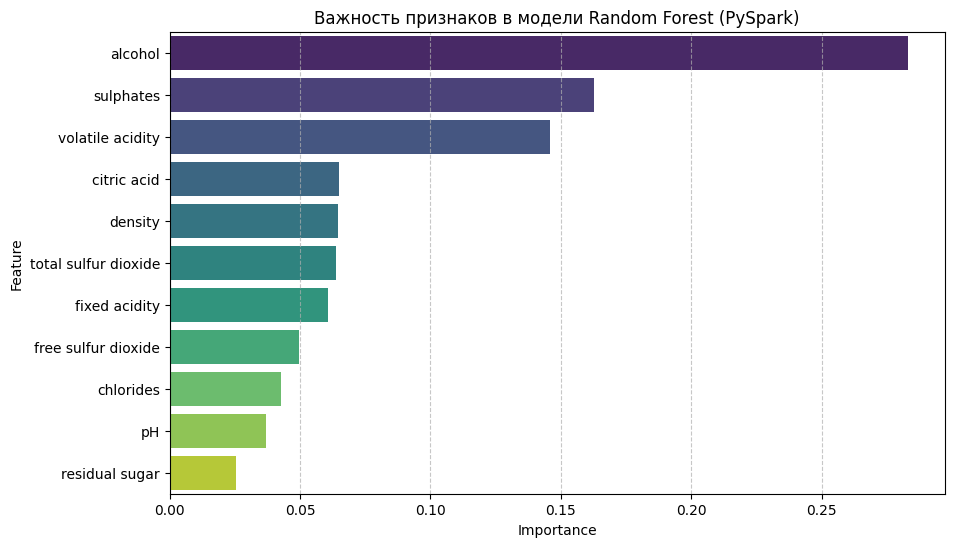

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Извлекаем важность признаков из модели
importances = model.featureImportances.toArray()
feature_names = [col for col in df.columns if col != 'label']

# Создаем Pandas DataFrame для удобства визуализации
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Важность признаков в модели Random Forest (PySpark)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()